# 03. Geometry basics: scaling, normy, odległości i cosine similarity

Ten notebook jest pomostem do KNN, clusteringu, SVM, PCA, regularizacji i embeddingów.

Główna intuicja:

$$
\text{większość algorytmów widzi dane jako punkty w przestrzeni}
$$

Jeżeli punkty są w przestrzeni, to musimy rozumieć:

- skale cech,
- normy,
- odległości,
- kąty i podobieństwo cosinusowe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, normalize
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

pd.set_option('display.precision', 4)

## 1. Punkt jako wektor

Przykładowy punkt w 2D:

$$
x = (x_1, x_2)
$$

W ML jeden obiekt to często wektor cech:

$$
x_i = [\text{cecha}_1, \text{cecha}_2, \ldots, \text{cecha}_p]
$$

Cała tabela danych to macierz:

$$
X =
\begin{bmatrix}
- & x_1 & - \\
- & x_2 & - \\
& \vdots & \\
- & x_n & -
\end{bmatrix}
$$

In [2]:
points = pd.DataFrame({
    'name': ['A', 'B', 'C'],
    'x1': [1, 4, 1],
    'x2': [1, 2, 5]
})
points

  name  x1  x2
0    A   1   1
1    B   4   2
2    C   1   5

<cell-last>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


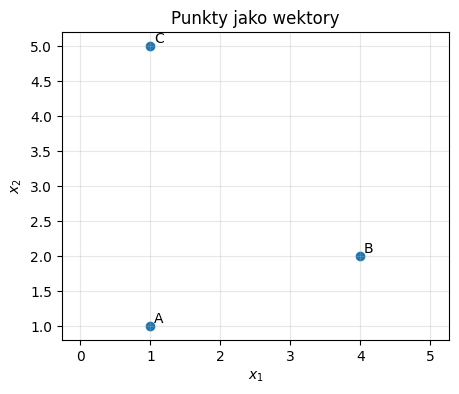

In [3]:
plt.figure(figsize=(5, 4))
plt.scatter(points['x1'], points['x2'])
for _, row in points.iterrows():
    plt.text(row['x1'] + 0.05, row['x2'] + 0.05, row['name'])
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Punkty jako wektory')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 2. Normy

Norma mierzy „długość” wektora.

Norma L2, czyli euklidesowa:

$$
\|x\|_2 = \sqrt{x_1^2+x_2^2+\ldots+x_p^2}
$$

Norma L1, czyli Manhattan:

$$
\|x\|_1 = |x_1|+|x_2|+\ldots+|x_p|
$$

Norma maksimum:

$$
\|x\|_\infty = \max_j |x_j|
$$

In [4]:
v = np.array([3, 4])

pd.DataFrame({
    'norma': ['L1', 'L2', 'L_inf'],
    'wartosc': [np.linalg.norm(v, ord=1), np.linalg.norm(v, ord=2), np.linalg.norm(v, ord=np.inf)]
})

   norma  wartosc
0     L1      7.0
1     L2      5.0
2  L_inf      4.0

## 3. Odległość euklidesowa

Odległość między punktami $a$ i $b$ to długość wektora różnicy:

$$
d(a,b)=\|a-b\|_2
$$

czyli w 2D:

$$
d(a,b)=\sqrt{(a_1-b_1)^2+(a_2-b_2)^2}
$$

In [5]:
X_points = points[['x1', 'x2']].values
D = euclidean_distances(X_points, X_points)
pd.DataFrame(D, index=points['name'], columns=points['name'])

name       A       B       C
name                        
A     0.0000  3.1623  4.0000
B     3.1623  0.0000  4.2426
C     4.0000  4.2426  0.0000

## 4. Dlaczego scaling jest ważny?

Jeżeli jedna cecha ma zakres 0–10, a druga 0–100000, to druga cecha może zdominować odległość.

Przykład: mamy trzy osoby opisane przez wiek i dochód. Bez skalowania dochód zdominuje odległość, bo liczby są większe.

In [6]:
people = pd.DataFrame({
    'person': ['A', 'B', 'C'],
    'age': [22, 24, 55],
    'income': [4000, 9000, 9500]
})
people

  person  age  income
0      A   22    4000
1      B   24    9000
2      C   55    9500

In [7]:
X_raw = people[['age', 'income']].values
D_raw = euclidean_distances(X_raw, X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
D_scaled = euclidean_distances(X_scaled, X_scaled)

print('Odległości bez skalowania:')
print(pd.DataFrame(D_raw, index=people['person'], columns=people['person']))
print('\nOdległości po StandardScaler:')
print(pd.DataFrame(D_scaled, index=people['person'], columns=people['person']))

Odległości bez skalowania:
person          A          B          C
person                                 
A          0.0000  5000.0004  5500.0990
B       5000.0004     0.0000   500.9601
C       5500.0990   500.9601     0.0000

Odległości po StandardScaler:
person       A       B       C
person                        
A       0.0000  2.0178  3.1108
B       2.0178  0.0000  2.0619
C       3.1108  2.0619  0.0000


In [8]:
scaled_people = pd.DataFrame(X_scaled, columns=['age_scaled', 'income_scaled'])
scaled_people.insert(0, 'person', people['person'])
scaled_people

  person  age_scaled  income_scaled
0      A     -0.7723        -1.4094
1      B     -0.6399         0.6040
2      C      1.4121         0.8054

### Intuicja

Bez skalowania pytanie brzmi głównie: „kto ma podobny dochód?”.

Po skalowaniu pytanie brzmi: „kto jest podobny w sensie wieku i dochodu, gdy obie cechy mają porównywalną wagę?”.

To jest krytyczne dla:

- KNN,
- k-means,
- SVM z odległościami/marginesem,
- PCA,
- regularyzacji.

## 5. StandardScaler i MinMaxScaler

StandardScaler:

$$
z = \frac{x-\mu}{\sigma}
$$

MinMaxScaler:

$$
x' = \frac{x-x_{min}}{x_{max}-x_{min}}
$$

StandardScaler jest naturalny dla modeli liniowych, SVM, PCA i regularyzacji. MinMaxScaler bywa wygodny, gdy chcemy mieć wartości w przedziale $[0,1]$.

In [9]:
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X_raw)

pd.DataFrame({
    'person': people['person'],
    'age_minmax': X_minmax[:, 0],
    'income_minmax': X_minmax[:, 1],
    'age_standard': X_scaled[:, 0],
    'income_standard': X_scaled[:, 1]
})

  person  age_minmax  income_minmax  age_standard  income_standard
0      A      0.0000         0.0000       -0.7723          -1.4094
1      B      0.0606         0.9091       -0.6399           0.6040
2      C      1.0000         1.0000        1.4121           0.8054

## 6. Cosine similarity

Cosine similarity porównuje kierunek wektorów, a nie ich długość:

$$
\cos(x,y)=\frac{x\cdot y}{\|x\|\|y\|}
$$

W tekstach i embeddingach często interesuje nas kierunek: czy dwa dokumenty mają podobny profil słów, nawet jeśli jeden jest dużo dłuższy.

In [10]:
docs = pd.DataFrame({
    'doc': ['A: kot pies kot', 'B: kot pies kot x2', 'C: ryba ryba ryba'],
    'kot': [2, 4, 0],
    'pies': [1, 2, 0],
    'ryba': [0, 0, 3]
})
X_docs = docs[['kot', 'pies', 'ryba']].values
cos = cosine_similarity(X_docs)

docs

                  doc  kot  pies  ryba
0     A: kot pies kot    2     1     0
1  B: kot pies kot x2    4     2     0
2   C: ryba ryba ryba    0     0     3

In [11]:
pd.DataFrame(cos, index=docs['doc'], columns=docs['doc'])

doc                 A: kot pies kot  B: kot pies kot x2  C: ryba ryba ryba
doc                                                                       
A: kot pies kot                 1.0                 1.0                0.0
B: kot pies kot x2              1.0                 1.0                0.0
C: ryba ryba ryba               0.0                 0.0                1.0

Dokumenty A i B mają cosine similarity równe $1$, bo są w tym samym kierunku:

$$
B = 2A
$$

Euklidesowo są różne, ale kierunkowo identyczne.

## 7. Jak geometria spina przyszłe tematy?

- KNN: wybieramy najbliższych sąsiadów według odległości.
- k-means: minimalizujemy odległości punktów od centroidów.
- SVM: szukamy hiperplanu z dużym marginesem.
- Ridge/Lasso: nakładamy geometryczne ograniczenia na współczynniki.
- PCA: szukamy kierunków największej wariancji.
- Embeddingi: często porównujemy obiekty przez cosine similarity.

## Proste ćwiczenia

1. Policz ręcznie odległość euklidesową między punktami $A=(1,1)$ i $B=(4,2)$.
2. Dlaczego dochód zdominował odległość bez skalowania?
3. Kiedy cosine similarity jest lepsze niż odległość euklidesowa?
4. Co stanie się z KNN, jeśli jedna cecha jest w kilometrach, a druga w milimetrach?